# Test 13
## APCEMM PCE Creation
Aircraft Type: B737-800

Engine Type: CFM56

### Initial Conditions
RHi Mean: 117

RHi Normalized Variance: from ERA5

### Temporal Conditions
RHi Normalized Variance: 0

Static test! ^^^


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import importlib.util
import yaml
from scipy.stats import norm
import pandas as pd
from scipy.stats import gaussian_kde
from scipy.integrate import simps
from scipy.interpolate import interp1d

# Import functions from the pipeline_fxn_lib.py script
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib

In [2]:
test_id = "test_13"

# Load .npy files into variables
coefficients = np.load(f"/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/{test_id}/PCE_coefficients.npy")
alpha = np.load(f"/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/{test_id}/PCE_alpha_set.npy")
predicted_validation_solutions = np.load(f"/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/{test_id}/predicted_validation_solutions.npy")
true_validation_solutions = np.load(f"/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/{test_id}/true_validation_solutions.npy")
true_training_solutions = np.load(f"/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/{test_id}/true_training_solutions.npy")
training_samples_matrix_offline = np.load(f"/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/{test_id}/training_samples_matrix_offline_cleaned.npy")
validation_samples_matrix_offline = np.load(f"/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/{test_id}/validation_samples_matrix_offline_cleaned.npy")
timesteps = len(training_samples_matrix_offline[0,0,:])

test_specifications_path = f"/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_data_sets/{test_id}/test_specifications.yaml"
# Load the saved YAML dictionary
with open(test_specifications_path, "r") as f:
    spec_dict = yaml.unsafe_load(f)

# Reconstruct the APCEMMConfig object using the loaded dictionary
test_specifications = lib.APCEMMConfig()

# Update the object with the loaded parameters
for key, value in spec_dict.items():
    setattr(test_specifications, key, value)

# Compute discrepancy distribution

In [3]:
base_parquet_dir = '/home/chinahg/GCresearch/contrailuncertainty/Met_processing/' # Directory where the parquet files are saved: should match that in met_matching.py

# get pdfs for each variable
gruan_RHi, era5_RHi, gruan_RHi_pdf, era5_RHi_pdf = lib.get_initial_dist(base_parquet_dir, already_combined=True) #, gruan_MLD_pdf, era5_MLD_pdf


Loading combined DataFrame from parquet file...
Extracting GRUAN and ERA5 data...
G_site            object
G_lat             object
G_lon             object
G_alt             object
G_T               object
G_RHi             object
G_MLD             object
G_dt              object
E_T_diffused      object
E_RHi_diffused    object
E_MLD_diffused    object
dtype: object
Rows in the combined DataFrame:
     G_site                                              G_lat  \
0       LIN  [52.209335, 52.20934, 52.20934, 52.20936, 52.2...   
1       LIN  [52.209347, 52.20932, 52.209312, 52.209297, 52...   
2       LIN  [52.209255, 52.209248, 52.209312, 52.20934, 52...   
3       LIN  [52.209316, 52.20935, 52.20935, 52.209305, 52....   
4       LIN  [52.209248, 52.209255, 52.209255, 52.20926, 52...   
...     ...                                                ...   
5287    LIN  [52.20934, 52.209396, 52.209347, 52.209335, 52...   
5288    LIN  [52.20927, 52.20927, 52.20927, 52.20927, 52.20...   
528

In [4]:
# true_data = gruan_RHi[0:1000]*100
# approx_data = era5_RHi[0:1000]  # Ensure same length for comparison

# # --- Fit KDEs ---
# kde_true = gruan_RHi_pdf
# kde_approx = era5_RHi_pdf

np.random.seed(0)
true_data = np.random.normal(loc=0, scale=1, size=1000)
approx_data = np.random.normal(loc=0.2, scale=1.2, size=1000)

# --- Fit KDEs ---
kde_true = lib.gaussian_kde(true_data)
kde_approx = lib.gaussian_kde(approx_data)

# --- Evaluation grid ---
x_vals = np.linspace(0,
                     140,
                     1000)

pdf_true = kde_true(x_vals)
pdf_approx = kde_approx(x_vals)

# --- Compute pointwise absolute error ---
abs_error = np.abs(pdf_true - pdf_approx)

# --- Compute local uncertainty for each sampled point in approx_data ---
# We'll interpolate the KDE values to get uncertainty at those points

true_interp = interp1d(x_vals, pdf_true, bounds_error=False, fill_value=0)
approx_interp = interp1d(x_vals, pdf_approx, bounds_error=False, fill_value=0)
print("length of approx_data", len(approx_data))
print("length of x_vals", len(x_vals))

uncertainty_at_samples = np.abs(true_interp(approx_data) - approx_interp(approx_data))
local_variance = uncertainty_at_samples**2  # Optionally scaled if needed
print("length of local variance", len(local_variance))

# --- Compute global metrics ---
# Integrated Absolute Error (IAE)
iae = simps(abs_error, x_vals)

# KL Divergence (avoid divide by zero)
mask = (pdf_true > 0) & (pdf_approx > 0)
kl_div = np.sum(pdf_true[mask] * np.log(pdf_true[mask] / pdf_approx[mask]) * (x_vals[1] - x_vals[0]))


length of approx_data 1000
length of x_vals 1000
length of local variance 1000


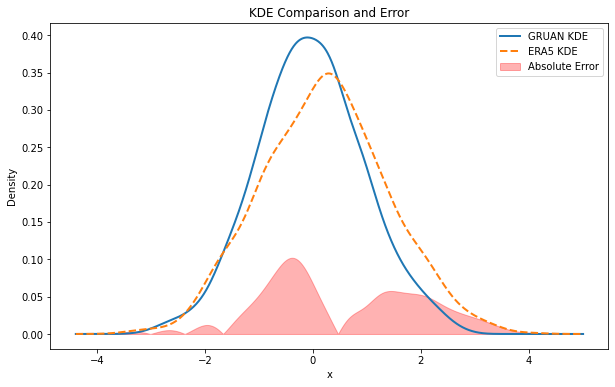

Integrated Absolute Error (IAE): 0.2387
KL Divergence: 0.0510
Sample of Local Variances (first 10): [1.00668192e-03 2.97005358e-03 1.00619527e-02 3.83890852e-04
 1.28054701e-06 1.00214676e-05 9.57563533e-04 1.44605504e-04
 2.14740441e-03 8.16224372e-06]


In [5]:
# --- Replace these with your actual data ---
# Simulated example data
np.random.seed(0)
true_data = np.random.normal(loc=0, scale=1, size=1000)
approx_data = np.random.normal(loc=0.2, scale=1.2, size=1000)

# --- Fit KDEs ---
kde_true = gaussian_kde(true_data)
kde_approx = gaussian_kde(approx_data)

# --- Evaluation grid ---
x_vals = np.linspace(min(true_data.min(), approx_data.min()) - 1,
                     max(true_data.max(), approx_data.max()) + 1,
                     1000)

pdf_true = kde_true(x_vals)
pdf_approx = kde_approx(x_vals)

# --- Compute pointwise absolute error ---
abs_error = np.abs(pdf_true - pdf_approx)

# --- Compute local uncertainty for each sampled point in approx_data ---
# We'll interpolate the KDE values to get uncertainty at those points

true_interp = interp1d(x_vals, pdf_true, bounds_error=False, fill_value=0)
approx_interp = interp1d(x_vals, pdf_approx, bounds_error=False, fill_value=0)

uncertainty_at_samples = np.abs(true_interp(approx_data) - approx_interp(approx_data))
local_variance = uncertainty_at_samples**2  # Optionally scaled if needed

# --- Compute global metrics ---
# Integrated Absolute Error (IAE)
iae = simps(abs_error, x_vals)

# KL Divergence (avoid divide by zero)
mask = (pdf_true > 0) & (pdf_approx > 0)
kl_div = np.sum(pdf_true[mask] * np.log(pdf_true[mask] / pdf_approx[mask]) * (x_vals[1] - x_vals[0]))

# --- Plot results ---
plt.figure(figsize=(10, 6))
plt.plot(x_vals, pdf_true, label='GRUAN KDE', lw=2)
plt.plot(x_vals, pdf_approx, label='ERA5 KDE', lw=2, linestyle='--')
plt.fill_between(x_vals, abs_error, alpha=0.3, color='red', label='Absolute Error')
plt.title('KDE Comparison and Error')
plt.legend()
plt.xlabel('x')
plt.ylabel('Density')
plt.show()

# --- Output summaries ---
print(f"Integrated Absolute Error (IAE): {iae:.4f}")
print(f"KL Divergence: {kl_div:.4f}")
print("Sample of Local Variances (first 10):", local_variance[:10])


Running Sobol sensitivity analysis...
Number of uncertain variables: 1
Sensitivity keys: dict_keys(['S_T_0'])


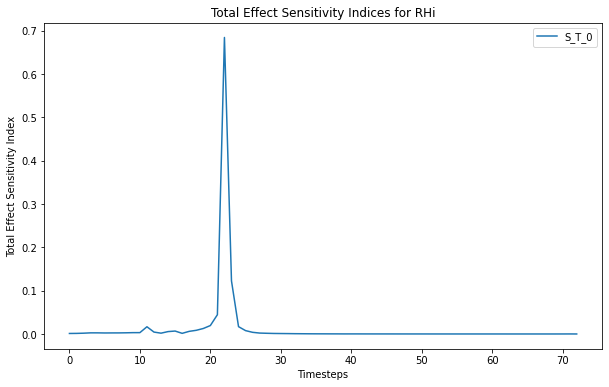

In [6]:
#################################################################################################################################################
### Pipeline Step 7: Sobol Sensitivity Analysis
print("Running Sobol sensitivity analysis...")
results_dir = f"/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/{test_id}/"
# Load the coefficients and alpha set from the saved files
coefficients = np.load(f"{results_dir}/PCE_coefficients.npy")
alpha = np.load(f"{results_dir}/PCE_alpha_set.npy")

print("Number of uncertain variables:", test_specifications.polynomial_degree)

S_T = lib.compute_total_effect_sensitivity_indices(coefficients, test_specifications.polynomial_degree)

print("Sensitivity keys:", S_T.keys())

# Normalize the total effect sensitivity indices
S_T_normalized = {}
for key, values in S_T.items():
    S_T_normalized[key] = values / np.sum(values, axis=0)  # Normalize by the sum of each column

# Flip the order of S_T_normalized for plotting
for key, values in S_T_normalized.items():
    S_T_normalized[key] = np.flip(values, axis=0)

# Plot the total effect sensitivity indices for all timesteps
plt.figure(figsize=(10, 6))

for key, values in S_T_normalized.items():
    plt.plot(values, label=key)

#plt.plot(S_T['MLD'], label='MLD', color='red')
plt.xlabel('Timesteps')
plt.ylabel('Total Effect Sensitivity Index')
plt.title('Total Effect Sensitivity Indices for RHi')
plt.legend()
plt.savefig(f"{results_dir}/total_effect_sensitivity_indices.png")
plt.show()


Shape of validation optical depth: (50, 73)


Text(0, 0.5, 'Surrogate Run')

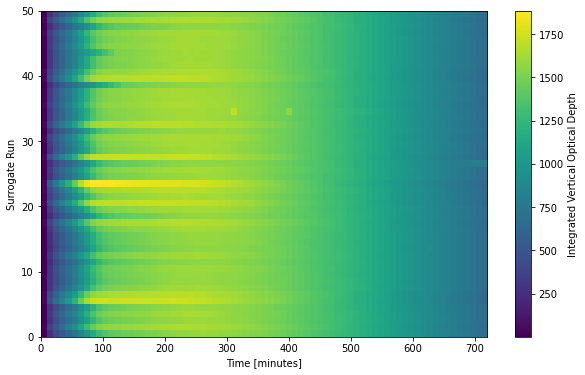

In [7]:
#################################################################################################
### Pipeline Step 8: Calculate the average lifetime integrated optical depth

# Import the cleaned validation samples matrix
clean_validation_samples_matrix_offline = np.load(f"/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/{test_id}/validation_samples_matrix_offline_cleaned.npy")

# Integrate all the vertical optical depth values from the validation dataset
validation_optical_depth = clean_validation_samples_matrix_offline[1, :, :]  # index 1 corresponds to optical depth
time_array = np.arange(0, timesteps)*10  # Create a time array for the x-axis, minutes
print("Shape of validation optical depth:", validation_optical_depth.shape)

# Plot the validation optical depth
plt.figure(figsize=(10, 6))
plt.imshow(validation_optical_depth, aspect='auto', cmap=cm.viridis, extent=[time_array[0], time_array[-1], 0, validation_optical_depth.shape[0]])
plt.colorbar(label='Integrated Vertical Optical Depth')
plt.xlabel('Time [minutes]')
plt.ylabel('Surrogate Run')

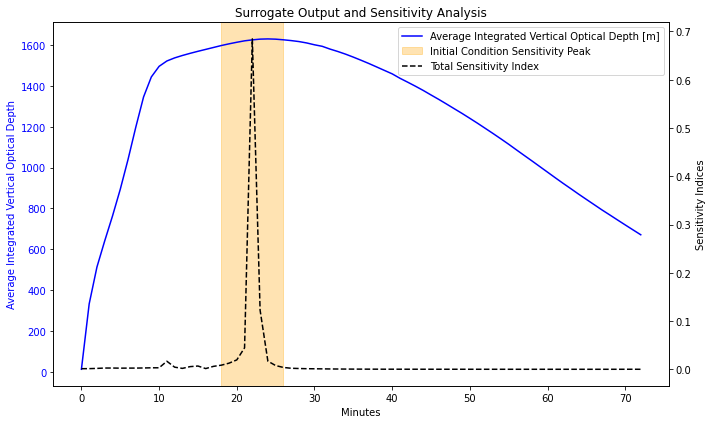

In [8]:
# Plot the average validation optical depth for each timestep
average_validation_optical_depth = np.mean(validation_optical_depth, axis=0)
std_validation_optical_depth = np.std(validation_optical_depth, axis=0)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the average validation optical depth on the primary y-axis
ax1.plot(average_validation_optical_depth, label='Average Integrated Vertical Optical Depth [m]', color='blue')
ax1.axvspan(18, 26, color='orange', alpha=0.3, label='Initial Condition Sensitivity Peak')
ax1.set_xlabel('Minutes')
ax1.set_ylabel('Average Integrated Vertical Optical Depth', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary y-axis for the sensitivity analysis
ax2 = ax1.twinx()
for key, values in S_T_normalized.items():
    ax2.plot(values, label=f'Total Sensitivity Index', linestyle='--', color='black')
ax2.set_ylabel('Sensitivity Indices', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add a combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Surrogate Output and Sensitivity Analysis')
plt.tight_layout()
plt.show()

In [9]:
# Integrate the optical depth over time for each validation run
lifetime_integrated_optical_depth = np.zeros(validation_optical_depth.shape[0])
for i in range(validation_optical_depth.shape[0]):
    # Integrate the optical depth over time for each validation run
    lifetime_integrated_optical_depth[i] = np.trapz(validation_optical_depth[i, :], dx=1)  # Assuming uniform time steps

# Calculate the average lifetime integrated optical depth across all validation runs
average_lifetime_integrated_optical_depth = np.mean(lifetime_integrated_optical_depth)

print("Average Lifetime Integrated Optical Depth [m min]:", average_lifetime_integrated_optical_depth)

# Your data
data = lifetime_integrated_optical_depth
mu, std = np.mean(data), np.std(data)

# # Plot
# fig, ax1 = plt.subplots(figsize=(10, 6))

# # First y-axis for the histogram
# ax1.bar(bins[:-1], prob_percent, width=bin_width, alpha=0.6, color='g', align='edge', label='Histogram (Probability %)')
# ax1.set_xlabel('Lifetime Integrated Optical Depth [m min]')
# ax1.set_ylabel('Probability [%]', color='g')
# ax1.tick_params(axis='y', labelcolor='g')
# ax1.set_title('Probability Distribution of Lifetime Integrated Optical Depth')

# # Second y-axis for the KDE
# ax2 = ax1.twinx()
# ax2.plot(x_plot, kde_percent, 'k-', linewidth=2, label='KDE (Probability %)')
# ax2.set_ylabel('KDE Probability [%]', color='k')
# ax2.tick_params(axis='y', labelcolor='k')

# # Add legends
# fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.85))
# plt.tight_layout()
# plt.show()


Average Lifetime Integrated Optical Depth [m min]: 90703.56098459962


# LRT analysis

In [10]:
### FUNCTION LIBRARY ###

def updateInput(filepath, attributes, contrail, type):
    """
    Update the input file with the given attributes.

    Parameters:
    - filepath (str): The path of the input file to be updated.
    - attributes (object): An object containing the attributes to be written to the input file.
    - contrail (bool): A flag indicating whether the input file is for contrail simulation or not.

    Returns:
    None
    """
    file = open(filepath,"w")
    if contrail == True and type == "water":
        file.writelines(["rte_solver "+attributes.rte_solver[0]+"\n",
                            "source "+attributes.source[0]+"\n",
                            "sza "+attributes.sza[0]+"\n",
                            "wavelength "+attributes.wavelength[0]+"\n",
                            "mol_abs_param "+attributes.mol_abs_param[0]+"\n",
                            "umu "+attributes.umu[0]+"\n",
                            "output_user "+attributes.output_user[0]+"\n",
                            "zout "+attributes.zout[0]+"\n",
                            "output_process "+attributes.output_process[0]+"\n",
                            "atmosphere_file "+str(attributes.atmosphere_file[0])+"\n",
                            "wc_file 1D cloud.in\n",
                            "quiet"])
        file.close()
    elif contrail == True and type == "ice":
        file.writelines(["rte_solver "+attributes.rte_solver[0]+"\n",
                            "source "+attributes.source[0]+"\n",
                            "sza "+attributes.sza[0]+"\n",
                            "wavelength "+attributes.wavelength[0]+"\n",
                            "mol_abs_param "+attributes.mol_abs_param[0]+"\n",
                            "umu "+attributes.umu[0]+"\n",
                            "output_user "+attributes.output_user[0]+"\n",
                            "zout "+attributes.zout[0]+"\n",
                            "output_process "+attributes.output_process[0]+"\n",
                            "atmosphere_file "+str(attributes.atmosphere_file[0])+"\n", 
                            "ic_habit "+str(attributes.ic_habit[0])+"\n",
                            "ic_properties "+str(attributes.ic_properties[0])+"\n",
                            "ic_file 1D "+attributes.ic_file[0]+"\n",
                            "ic_modify tau set " +attributes.ic_modify[0]+"\n",
                            "quiet"])
        file.close()
    else: 
        file.writelines(["rte_solver "+attributes.rte_solver[0]+"\n",
                            "source "+attributes.source[0]+"\n",
                            "sza "+attributes.sza[0]+"\n",
                            "wavelength "+attributes.wavelength[0]+"\n",
                            "mol_abs_param "+attributes.mol_abs_param[0]+"\n",
                            "umu "+attributes.umu[0]+"\n",
                            "output_user "+attributes.output_user[0]+"\n",
                            "zout "+attributes.zout[0]+"\n",
                            "output_process "+attributes.output_process[0]+"\n",
                            "atmosphere_file "+str(attributes.atmosphere_file[0])+"\n",
                            "quiet\n"])
        file.close()
    
def clearskyRF(attributes):
    """
    Run the clear sky radiative forcing simulation.

    Parameters:
    - attributes (object): An object containing the attributes for the simulation.

    Returns:
    - LRToutput (list): A list containing the output of the simulation.
    """
    updateInput("/home/chinahg/GCresearch/contrailuncertainty/LRT/thermal-clear.in", attributes, False, "None")
    LRToutput = !LD_LIBRARY_PATH=/data/home/chinahg/.conda/envs/afca-test/lib:$LD_LIBRARY_PATH /home/iross/misc-code/libRadtran/bin/uvspec < /home/chinahg/GCresearch/contrailuncertainty/LRT/thermal-clear.in # [X,X,X,net TOA flux]
    return LRToutput

def contrailRF(attributes, type):
    """
    Run the contrail radiative forcing simulation.

    Parameters:
    - attributes (object): An object containing the attributes for the simulation.

    Returns:
    - LRToutput (list): A list containing the output of the simulation.
    """
    updateInput("/home/chinahg/GCresearch/contrailuncertainty/LRT/thermal-cloud.in", attributes, True, type)
    LRToutput = !LD_LIBRARY_PATH=/data/home/chinahg/.conda/envs/afca-test/lib:$LD_LIBRARY_PATH /home/iross/misc-code/libRadtran/bin/uvspec < /home/chinahg/GCresearch/contrailuncertainty/LRT/thermal-cloud.in # [X,X,X,X,X,net TOA flux]
    return LRToutput

def reformatResults(resultsRaw):
    """
    Reformat the raw results.

    Parameters:
    - resultsRaw (list): A list containing the raw results.

    Returns:
    - li (list): A list containing the reformatted results.
    """
    string = str(resultsRaw[0].strip().replace("  ", " "))
    li = list(string.split(" ")) 
    return li

### RF analysis for a single APCEMM run at multiple timestamps

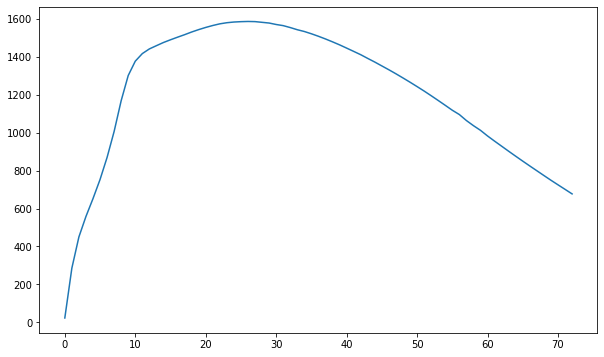

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(predicted_validation_solutions[0, :])

In [12]:
avg_contrail_width = 5000 # [m], Duda 2013

In [13]:
# Set-up 
rte_solver = "disort" # 1D radiative transfer solver (DIScrete ORdinaTe solver)
source = "thermal" # Absorbing on the thermal spectrum (not solar)
sza = "0" # Solar zenith angle
wavelength = "2500 80000" # Wavelength range to compute over
mol_abs_param = "reptran fine" # spectral resolution (fine/medium)
umu = "1.0" # cosine of the viewing zenith angle
output_user = "edir eglo edn eup enet esum" # The direct, global, diffuse downward, 
                                            #and diffuse upward irradiance. Net is 
                                            #global - upward, sum is global + upward.
zout = "TOA" # Top of atmosphere (where total flux is calculated)
output_process = "integrate" # Integrate over wavelength
atmosphere_file = "US-standard" # Standard atmosphere type
ic_habit = "plate"

ic_properties = "yang"
ic_file = "/home/chinahg/GCresearch/contrailuncertainty/LRT/ice.in"
wc_file = "/home/chinahg/GCresearch/contrailuncertainty/LRT/cloud.in"

In [ ]:
# Contrail flux
import tqdm

for j in range(len(predicted_validation_solutions[:, 0])):
   print(f"Contrail flux for validation run {j+1} out of {len(predicted_validation_solutions[:,0])}")
   tau = predicted_validation_solutions[j, :]/avg_contrail_width
   contrailFlux = np.zeros(len(tau))

   for i in tqdm.tqdm(range(len(tau))):
     print("Calculating contrail flux...")
     tau_i = str(tau[i])
     inputs = {'rte_solver': [rte_solver], 'source': [source], 'sza': [sza], 'wavelength': [wavelength], 'mol_abs_param': [mol_abs_param], 'umu': [umu], 'output_user': [output_user], 
          'zout': [zout], 'output_process': [output_process], 'atmosphere_file': [atmosphere_file], 'ic_habit': [ic_habit], 'ic_properties': [ic_properties], 'ic_file': [ic_file],
          'ic_modify': [tau_i]}
     
     attributes = pd.DataFrame(data = inputs)
     contrailFluxRaw = contrailRF(attributes,"ice")
     contrailFlux[i] = reformatResults(contrailFluxRaw)[-1]

     # Save contrailFlux values to a CSV file
     contrail_flux_df = pd.DataFrame({'contrail_flux': contrailFlux})
     contrail_flux_df.to_csv(f'contrail_flux_{j+1}.csv', index=False)
         

Contrail flux for validation run 1 out of 50


  0%|          | 0/73 [00:00<?, ?it/s]

Calculating contrail flux...


  1%|▏         | 1/73 [00:47<56:26, 47.03s/it]

Calculating contrail flux...


...

Calculating contrail flux...


 64%|██████▍   | 47/73 [36:24<19:52, 45.86s/it]

Calculating contrail flux...


 66%|██████▌   | 48/73 [37:09<19:00, 45.63s/it]

Calculating contrail flux...


In [ ]:
# Clear flux
inputs = {'rte_solver': [rte_solver], 'source': [source], 'sza': [sza], 'wavelength': [wavelength], 'mol_abs_param': [mol_abs_param], 'umu': [umu], 'output_user': [output_user], 
     'zout': [zout], 'output_process': [output_process], 'atmosphere_file': [atmosphere_file]}
attributes = pd.DataFrame(data = inputs)

clearFluxRaw = clearskyRF(attributes)
clearFlux = reformatResults(clearFluxRaw)[-1]

In [ ]:
clearFlux_plot = np.ones(len(contrailFlux)) * float(clearFlux)  # Create a constant array for clear flux
RF = clearFlux_plot - contrailFlux  # Calculate the radiative forcing

# Plot radiative forcing (RF) vs. index
plt.figure(dpi=100)
plt.scatter(np.linspace(0,len(RF)*10/60,len(RF)),RF, marker='x', color='red')
plt.title("LibRadTran Contrail Radiative Forcing Estimates")
plt.xlabel("Time [hours]")
plt.ylabel("Radiative Forcing [mW/m$^2$]")
plt.tight_layout()
plt.show()

### RF analysis for bulk individual APCEMM runs with int VOD

In [ ]:
import glob

# Find all contrail_flux CSV files in the current directory
csv_files = sorted(glob.glob('contrail_flux_*.csv'))

# Read all CSV files into a list of arrays
contrail_flux_arrays = [pd.read_csv(f)['contrail_flux'].values for f in csv_files]

# Stack arrays to shape (num_files, num_timesteps)
contrail_flux_matrix = np.vstack(contrail_flux_arrays)

# Calculate average, min, and max at each timestep (axis=0)
mean_flux = np.mean(contrail_flux_matrix, axis=0)
min_flux = np.min(contrail_flux_matrix, axis=0)
max_flux = np.max(contrail_flux_matrix, axis=0)

# Timesteps (assuming 10 min per step as above)
timesteps = np.arange(len(mean_flux))
time_minutes = timesteps * 10

# Plot with error bars (min/max)
plt.figure(figsize=(10, 6))
plt.errorbar(time_minutes, mean_flux, yerr=[mean_flux - min_flux, max_flux - mean_flux], fmt='-o', capsize=4, label='Average Contrail Flux')
plt.xlabel('Time [minutes]')
plt.ylabel('Contrail Flux [mW/m$^2$]')
plt.title('Average Contrail Flux with Min/Max Error Bars')
plt.legend()
plt.tight_layout()
plt.show()

### RF analysis for bulk APCEMM runs with integrated lifetime optical depth (change)

In [ ]:
# Sample the lifetime integrated optical depth from the fitted distribution
minutes_in_simulation = 720
sampled_lifetime_integrated_optical_depth = np.random.normal(mu, std, 100)/(minutes_in_simulation*avg_contrail_width)  # Adjust the number of samples as needed

In [ ]:
# Set-up 
rte_solver = "disort" # 1D radiative transfer solver (DIScrete ORdinaTe solver)
source = "thermal" # Absorbing on the thermal spectrum (not solar)
sza = "0" # Solar zenith angle
wavelength = "2500 80000" # Wavelength range to compute over
mol_abs_param = "reptran fine" # spectral resolution (fine/medium)
umu = "1.0" # cosine of the viewing zenith angle
output_user = "edir eglo edn eup enet esum" # The direct, global, diffuse downward, 
                                            #and diffuse upward irradiance. Net is 
                                            #global - upward, sum is global + upward.
zout = "TOA" # Top of atmosphere (where total flux is calculated)
output_process = "integrate" # Integrate over wavelength
atmosphere_file = "US-standard" # Standard atmosphere type
ic_habit = "plate"
tau = sampled_lifetime_integrated_optical_depth
ic_properties = "yang"
ic_file = "/home/chinahg/GCresearch/contrailuncertainty/LRT/ice.in"
wc_file = "/home/chinahg/GCresearch/contrailuncertainty/LRT/cloud.in"

In [ ]:
# Contrail flux
import tqdm
contrailFlux = np.zeros(len(tau))
for i in tqdm.tqdm(range(len(tau))):
    tau_i = str(tau[i])
    inputs = {'rte_solver': [rte_solver], 'source': [source], 'sza': [sza], 'wavelength': [wavelength], 'mol_abs_param': [mol_abs_param], 'umu': [umu], 'output_user': [output_user], 
         'zout': [zout], 'output_process': [output_process], 'atmosphere_file': [atmosphere_file], 'ic_habit': [ic_habit], 'ic_properties': [ic_properties], 'ic_file': [ic_file],
         'ic_modify': [tau_i]}
    attributes = pd.DataFrame(data = inputs)
    
    contrailFluxRaw = contrailRF(attributes,"ice")
    contrailFlux[i] = reformatResults(contrailFluxRaw)[-1]

In [ ]:
# Clear flux
inputs = {'rte_solver': [rte_solver], 'source': [source], 'sza': [sza], 'wavelength': [wavelength], 'mol_abs_param': [mol_abs_param], 'umu': [umu], 'output_user': [output_user], 
     'zout': [zout], 'output_process': [output_process], 'atmosphere_file': [atmosphere_file]}
attributes = pd.DataFrame(data = inputs)

clearFluxRaw = clearskyRF(attributes)
clearFlux = reformatResults(clearFluxRaw)[-1]

In [ ]:
clearFlux_plot = np.ones(len(contrailFlux)) * float(clearFlux)  # Create a constant array for clear flux
RF = clearFlux_plot - contrailFlux  # Calculate the radiative forcing

# Plot the difference between clear flux and contrail flux as a histogram
plt.figure(dpi=100)
plt.hist(np.abs(clearFlux_plot - contrailFlux), bins=30, color='red', alpha=0.7, edgecolor='black')

# Add labels and formatting
plt.title("LibRadTran Contrail Radiative Forcing Estimates")
plt.xlabel(r"Radiative Forcing $[mW/m^2]$")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the mean and standard deviation of RF
rf_mean = np.mean(RF)
rf_std = np.std(RF)

print(f"Mean of RF: {rf_mean}")
print(f"Standard Deviation of RF: {rf_std}")

# Plot as a gaussian distribution
x = np.linspace(rf_mean - 3*rf_std, rf_mean + 3*rf_std, 100)
y = norm.pdf(x, rf_mean, rf_std)

plt.figure(dpi=100)
plt.plot(x, y, color='red', label='Std: 0.041, Mean: 1.66')

plt.hist(RF, density=True, bins=20, alpha=0.5, color='blue', edgecolor='black', label='RF Histogram')
plt.title("LibRadTran Contrail Radiative Forcing Estimates")
plt.xlabel("RF (W/m^2)")
plt.ylabel("Normalized Density")
plt.legend()

# Old

In [ ]:
lw = 1
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 15), dpi=150, sharex=True, sharey=True)
num_colors = len(training_samples_matrix_offline[0,:,0])  # Number of unique colors needed
colors = cm.get_cmap('tab20', num_colors).colors  # Use 'tab20' colormap with `num_colors` unique colors

for subplot_idx, ax in enumerate(axes):
    for idx in range(subplot_idx * 5, (subplot_idx + 1) * 5):
        ax.plot(list(range(0, timesteps)), true_training_solutions[idx, :], label=f"Run {idx+1}", lw=lw, color=colors[idx % len(colors)])
    ax.set_ylabel("Integrated VOD [m]")
    ax.legend(fontsize=9)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

axes[-1].set_xlabel("Timestep")
plt.tight_layout()
plt.show()


### Validation of PCE created surrogate

In [ ]:
selected_runs = [2, 5, 8, 9, 16, 18]
fig, axes = plt.subplots(nrows=len(selected_runs), ncols=1, figsize=(10, 15), dpi=150, sharex=True)

time_min = timesteps * 10
time_points = np.linspace(0, time_min, timesteps)
line_styles = ["-", "--"]  # Solid, dashed
colors = plt.cm.tab10.colors[:len(selected_runs)]

for idx, run in enumerate(selected_runs):
    run = run + 1
    ax = axes[idx]
    ax.plot(time_points, true_validation_solutions[run, :], label=f"Run {run} - True", color=colors[idx % len(colors)], lw=lw, ls=line_styles[0])
    ax.plot(time_points, predicted_validation_solutions[run, :], label=f"Run {run} - PCE", color=colors[idx % len(colors)], lw=lw, ls=line_styles[1])
    ax.set_ylabel("Integrated VOD [m]")
    ax.legend(fontsize=9)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

axes[-1].set_xlabel("Timestep [min]")
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(nrows=len(selected_runs), ncols=1, figsize=(10, 15), dpi=150, sharex=True)

time_min = timesteps * 10
time_points = np.linspace(0, time_min, timesteps)
line_styles = ["-", "--"]  # Solid, dashed
colors = plt.cm.tab10.colors[:len(selected_runs)]

# Determine global y-axis limits
y_min = min(true_validation_solutions.min(), predicted_validation_solutions.min())
y_max = max(true_validation_solutions.max(), predicted_validation_solutions.max())

# Plot each selected validation run
for idx, run in enumerate(selected_runs):
    run = run + 1
    ax = axes[idx]
    initial_condition = validation_samples_matrix_offline[0, run, 0] + 117  # Extract the initial condition for the run
    ax.plot(time_points, true_validation_solutions[run, :], label=f"Run {run} - True (IC: {initial_condition:.2f})", color=colors[idx % len(colors)], lw=lw, ls=line_styles[0])
    ax.plot(time_points, predicted_validation_solutions[run, :], label=f"Run {run} - PCE", color=colors[idx % len(colors)], lw=lw, ls=line_styles[1])
    ax.set_ylabel("Integrated VOD [m]")
    ax.legend(fontsize=9)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_ylim(y_min, y_max)  # Set the same y-axis limits for all subplots

# Set the x-axis label for the last subplot
axes[-1].set_xlabel("Timestep [min]")

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# Calculate the average error per point across all runs
average_error_per_point = np.mean((true_validation_solutions - predicted_validation_solutions), axis=0)

# Print the average error for the first few timesteps
print("Average error per point across all runs (first few timesteps):")
print(average_error_per_point[:5])

In [ ]:
# Calculate the average of the true solutions
average_true_solutions = np.mean(true_validation_solutions, axis=0)
lower_bound = np.zeros(len(average_true_solutions))
upper_bound = np.zeros(len(average_true_solutions))

# Create the plot
fig, ax = plt.subplots(dpi=200)

time_hours = time_points / 60  # Convert time points to hours
colors = plt.cm.tab10.colors[0]  # Use a single color for the plot

# Plot the average of the true solutions
ax.plot(time_hours, average_true_solutions, label="Average True Solutions", color=colors, lw=lw)

# Add shaded region based on the average error per point
for i in range(len(average_error_per_point)):
    if average_error_per_point[i] < 0:
        lower_bound[i] = average_true_solutions[i] - average_error_per_point[i]
    else:
        lower_bound[i] = average_true_solutions[i]
    
    if average_error_per_point[i] >= 0:
        upper_bound[i] = average_true_solutions[i] - average_error_per_point[i]
    else:
        upper_bound[i] = average_true_solutions[i]
print(average_error_per_point)
ax.fill_between(time_hours, lower_bound, average_true_solutions, color=colors, alpha=0.2)
ax.fill_between(time_hours, upper_bound, average_true_solutions, color=colors, alpha=0.2, label="Average Error")

ax.set_ylabel("Integrated VOD [m]")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Set the x-axis label
ax.set_xlabel("Time [hours]")

# Add legend
ax.legend(fontsize=9)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(dpi=200)

time_hours = time_points / 60  # Convert time points to hours
line_styles = ["-", "--"]  # Solid, dashed
colors = plt.cm.tab10.colors[0]  # Use a single color for the plot

# Determine global y-axis limits
y_min = min(true_validation_solutions.min(), predicted_validation_solutions.min())
y_max = max(true_validation_solutions.max(), predicted_validation_solutions.max())

# Plot run 10
run = 10  # Run index
initial_condition = validation_samples_matrix_offline[0, run, 0] + 117  # Extract the initial condition for the run
ax.plot(time_hours, true_validation_solutions[run, :], label=f"APCEMM Data", color=colors, lw=lw, ls=line_styles[0])
ax.plot(time_hours, predicted_validation_solutions[run, :], label=f"Surrogate (PCE)", color=colors, lw=lw, ls=line_styles[1])

#------------------------------------------------------------------------------------------------------------------------------------
# Add shaded region based on the average error per point
for i in range(len(average_error_per_point)):
    if average_error_per_point[i] < 0:
        lower_bound[i] = true_validation_solutions[run, i] - average_error_per_point[i]
    else:
        lower_bound[i] = true_validation_solutions[run, i]
    
    if average_error_per_point[i] >= 0:
        upper_bound[i] = true_validation_solutions[run, i] - average_error_per_point[i]
    else:
        upper_bound[i] = true_validation_solutions[run, i]

ax.fill_between(time_hours, lower_bound, upper_bound, color=colors, alpha=0.2, label="Average Error")
#------------------------------------------------------------------------------------------------------------------------------------

ax.set_ylabel("Integrated VOD [m]")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_ylim(y_min, y_max)  # Set the same y-axis limits

# Add the initial condition as a text annotation
ax.text(0.20, 0.1, f"Initial Relative Humidity: {initial_condition:.0f}%", transform=ax.transAxes, fontsize=10, verticalalignment='top')

# Set the x-axis label
ax.set_xlabel("Time [hours]")

# Add legend
ax.legend(fontsize=9)

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# Flatten the validation samples to create a 1D array for the histogram
data = validation_samples_matrix_offline[0, :, 0] + 117

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, alpha=0.7, color='blue', edgecolor='black')

# Add integer ticks for the x-axis
x_ticks = range(int(data.min()), int(data.max()) + 1)  # Generate integer ticks
plt.xticks(x_ticks)

plt.xlabel("Validation Sample Values")
plt.ylabel("Frequency")
plt.title("Histogram of Validation Sample Values")
plt.tight_layout()
plt.show()


# Sensitivity Analysis of Novel-Sampled PCE Solutions

In [ ]:
# Example usage
num_variables = 3
S_T = lib.compute_total_effect_sensitivity_indices(coefficients, num_variables)

# Print the total effect sensitivity indices for the first few timesteps
print("Total Effect Sensitivity Indices (S_T) for first few timesteps:")
for key, values in S_T.items():
    print(f"{key}: {values[:5]}")  # Print first 5 timesteps for brevity

In [ ]:
# # Plot with two y-axes
# fig, ax1 = plt.subplots()
# # Plot GRUAN RHi KDE on the first y-axis
# ax1.plot(x_vals, gruan_RHi_pdf(x_vals), label='GRUAN RHi KDE', color='blue')
# ax1.set_xlabel('RHi')
# ax1.set_ylabel('GRUAN RHi Density', color='blue')
# ax1.tick_params(axis='y', labelcolor='blue')
# ax1.grid(True)
# # Create a second y-axis for ERA5 RHi KDE
# ax2 = ax1.twinx()
# ax2.plot(x_vals, era5_RHi_pdf(x_vals*100), label='ERA5 RHi KDE', linestyle='--', color='red')
# ax2.set_ylabel('ERA5 RHi Density', color='red')
# ax2.tick_params(axis='y', labelcolor='red')
# # Add title and legend
# plt.title('Kernel Density Estimate of GRUAN and ERA5 RHi')
# fig.tight_layout()
# plt.show()
# plt.savefig('/home/chinahg/GCresearch/contrailuncertainty/Met_processing/initial_distributions.png')

# # Save another plot of the GRUAN and ERA5 data, but truncated to our RHi range of interest
# # Create a grid of x values over the range of the data
# x_vals = np.linspace(0.6,1.4, 1000)
# # Plot with two y-axes
# fig, ax1 = plt.subplots()
# # Plot GRUAN RHi KDE on the first y-axis
# ax1.plot(x_vals, gruan_RHi_pdf(x_vals), label='GRUAN RHi KDE', color='blue')
# ax1.set_xlabel('RHi')
# ax1.set_ylabel('GRUAN RHi Density', color='blue')
# ax1.tick_params(axis='y', labelcolor='blue')
# ax1.grid(True)
# # Create a second y-axis for ERA5 RHi KDE
# ax2 = ax1.twinx()
# ax2.plot(x_vals, era5_RHi_pdf(x_vals*100), label='ERA5 RHi KDE', linestyle='--', color='red')
# ax2.set_ylabel('ERA5 RHi Density', color='red')
# ax2.tick_params(axis='y', labelcolor='red')
# # Add title and legend
# plt.title('Kernel Density Estimate of GRUAN and ERA5 RHi')
# fig.tight_layout()
# plt.show()
# plt.savefig('/home/chinahg/GCresearch/contrailuncertainty/Met_processing/RHi_IC_distributions_trunc.png')

# # Plot and save correlation between GRUAN and ERA5 data
# print("Number of GRUAN RHi values:", len(gruan_RHi))
# print("Number of ERA5 RHi values:", len(era5_RHi))
# plt.figure(figsize=(8, 6))
# plt.scatter(gruan_RHi*100, era5_RHi[0:len(gruan_RHi)], alpha=0.5, s=1)  # Set marker size to 5 for smaller dots
# plt.xlabel('GRUAN RHi')
# plt.ylabel('ERA5 RHi')
# plt.title('Correlation between GRUAN and ERA5 RHi')
# plt.grid(True)
# plt.xlim(0, 140)
# plt.ylim(0, 140)
# # Add a y=x line
# plt.plot([0, 140], [0, 140], color='green', linestyle='--')
# plt.legend()
# plt.show()
# plt.savefig('/home/chinahg/GCresearch/contrailuncertainty/Met_processing/RHi_correlation.png')

# # Plot the ERA5 RHi data, fitted to a gaussian distribution
# plt.figure(figsize=(8, 6))
# plt.hist(era5_RHi[era5_RHi > 50], bins=50, density=True, alpha=0.5, color='blue', label='ERA5 RHi')
# plt.xlabel('RHi')
# plt.ylabel('Density')
# plt.title('Histogram of ERA5 RHi')
# plt.grid(True)
# # Add a fitted gaussian distribution

# plt.plot(x_vals*100, norm.pdf(x_vals*100, mu, std), color='red', label='Fitted Gaussian')
# plt.legend()
# plt.show()
# plt.savefig('/home/chinahg/GCresearch/contrailuncertainty/Met_processing/fitted_gaussian_ERA5_RHi.png')